In [1]:
import json

with open("/Users/jitminaj/Downloads/vogue_images/designers.json") as f:
    vogue = json.load(f)

with open("/Users/jitminaj/Downloads/harpersbazaar_images/designers.json") as f:
    hb = json.load(f)

print("Vogue entries:", len(vogue))
print("Harper's entries:", len(hb))
print("\nVogue sample:", vogue[0])
print("Harper's sample:", hb[0])

Vogue entries: 32
Harper's entries: 129

Vogue sample: {'celebrity': 'Beyoncé', 'designer': 'Olivier Rousteing and Chopard', 'caption': 'Beyoncé in Olivier Rousteing and Chopard.'}
Harper's sample: {'index': 0, 'celebrity': 'Beyoncé', 'caption': 'Beyoncé In Custom Olivier Rousteing', 'designer': 'Custom Olivier Rousteing'}


In [2]:
import json

with open("/Users/jitminaj/Downloads/vogue_images/designers.json") as f:
    vogue = json.load(f)

with open("/Users/jitminaj/Downloads/harpersbazaar_images/designers.json") as f:
    hb = json.load(f)

print("Vogue sample:", vogue[0])
print("Harper's sample:", hb[0])

Vogue sample: {'celebrity': 'Beyoncé', 'designer': 'Olivier Rousteing and Chopard', 'caption': 'Beyoncé in Olivier Rousteing and Chopard.'}
Harper's sample: {'index': 0, 'celebrity': 'Beyoncé', 'caption': 'Beyoncé In Custom Olivier Rousteing', 'designer': 'Custom Olivier Rousteing'}


In [3]:
import sys
!{sys.executable} -m pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 33.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 34.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [4]:
import json
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load and merge
with open("/Users/jitminaj/Downloads/vogue_images/designers.json") as f:
    vogue = json.load(f)

with open("/Users/jitminaj/Downloads/harpersbazaar_images/designers.json") as f:
    hb = json.load(f)

# Standardise Harper's by dropping index
hb_clean = [{"celebrity": x["celebrity"], "designer": x["designer"], "caption": x["caption"]} for x in hb]

# Combine
all_data = vogue + hb_clean
df = pd.DataFrame(all_data)

# Filter unknowns
df = df[df["designer"] != "unknown"]

print(f"Total entries: {len(df)}")
print(df.head())

# Vectorise designer names using TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["designer"])

# Cluster into groups
kmeans = KMeans(n_clusters=5, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

# Show clusters
for i in range(5):
    print(f"\n--- Cluster {i} ---")
    print(df[df["cluster"] == i]["designer"].value_counts().head(10))

Total entries: 149
         celebrity                       designer  \
0          Beyoncé  Olivier Rousteing and Chopard   
1  Blue Ivy Carter   Balenciaga and Henry & Henry   
2            Jay-Z                  Louis Vuitton   
3   Venus Williams                      Swarovski   
4    Nicole Kidman                         Chanel   

                                            caption  
0         Beyoncé in Olivier Rousteing and Chopard.  
1  Blue Ivy Carter in Balenciaga and Henry & Henry.  
2                           Jay-Z in Louis Vuitton.  
3                      Venus Williams in Swarovski.  
4                          Nicole Kidman in Chanel.  

--- Cluster 0 ---
designer
Custom Swarovski                         2
Olivier Rousteing and Chopard            1
Balenciaga and Henry & Henry             1
Swarovski                                1
Allen Jones and Whitaker Malem           1
Giles Deacon and Herbert Levine          1
McQueen and Boucheron                    1
Burberry 

In [5]:
import sys
!{sys.executable} -m pip install scikit-learn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


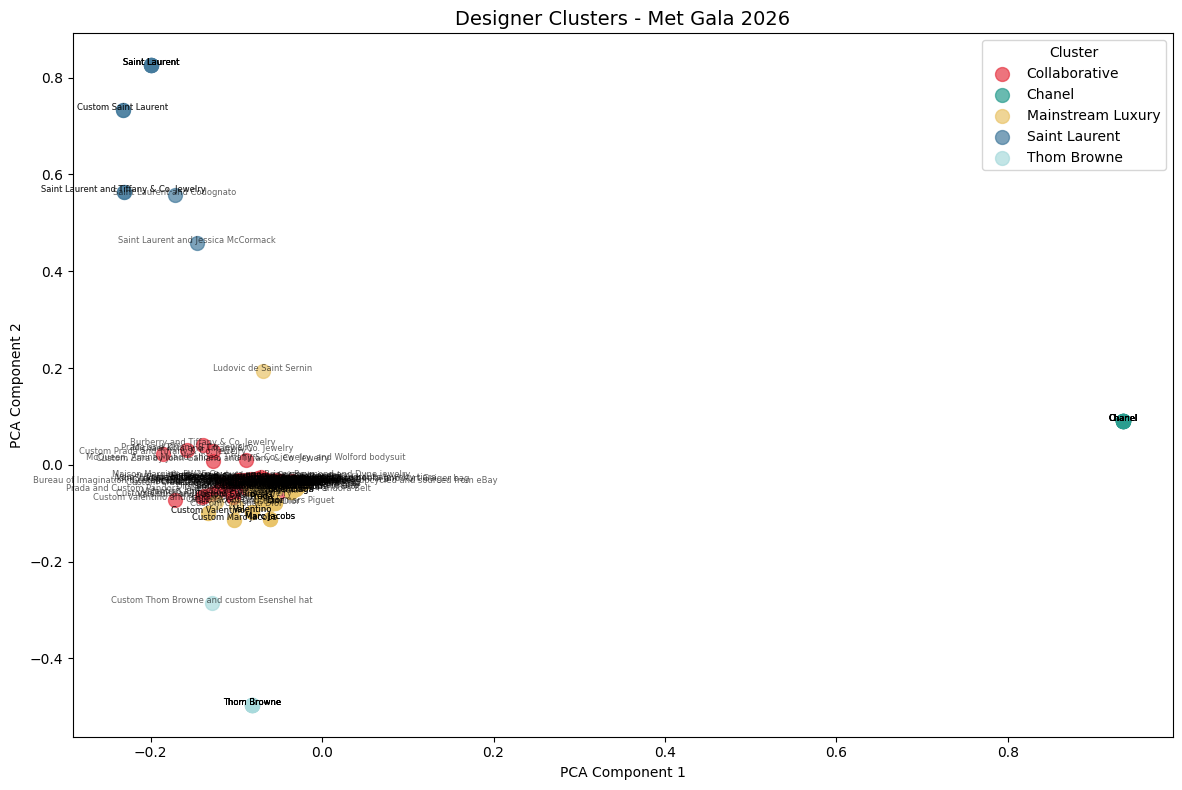

In [6]:
import json
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load and merge
with open("/Users/jitminaj/Downloads/vogue_images/designers.json") as f:
    vogue = json.load(f)

with open("/Users/jitminaj/Downloads/harpersbazaar_images/designers.json") as f:
    hb = json.load(f)

hb_clean = [{"celebrity": x["celebrity"], "designer": x["designer"], "caption": x["caption"]} for x in hb]

all_data = vogue + hb_clean
df = pd.DataFrame(all_data)
df = df[df["designer"] != "unknown"]

# Vectorise
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["designer"])

# Cluster
kmeans = KMeans(n_clusters=5, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

# Reduce to 2D for plotting
pca = PCA(n_components=2)
coords = pca.fit_transform(X.toarray())
df["x"] = coords[:, 0]
df["y"] = coords[:, 1]

# Plot
colors = ["#e63946", "#2a9d8f", "#e9c46a", "#457b9d", "#a8dadc"]
cluster_names = {
    0: "Collaborative",
    1: "Chanel",
    2: "Mainstream Luxury",
    3: "Saint Laurent",
    4: "Thom Browne"
}

fig, ax = plt.subplots(figsize=(12, 8))

for cluster_id in range(5):
    mask = df["cluster"] == cluster_id
    ax.scatter(
        df[mask]["x"],
        df[mask]["y"],
        label=cluster_names[cluster_id],
        color=colors[cluster_id],
        s=100,
        alpha=0.7
    )

# Label each point with designer name
for _, row in df.iterrows():
    ax.annotate(
        row["designer"],
        (row["x"], row["y"]),
        fontsize=6,
        alpha=0.6,
        ha="center"
    )

ax.set_title("Designer Clusters - Met Gala 2026", fontsize=14)
ax.legend(title="Cluster")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
plt.tight_layout()
plt.show()

In [10]:
import sys
!{sys.executable} -m pip install adjustText


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


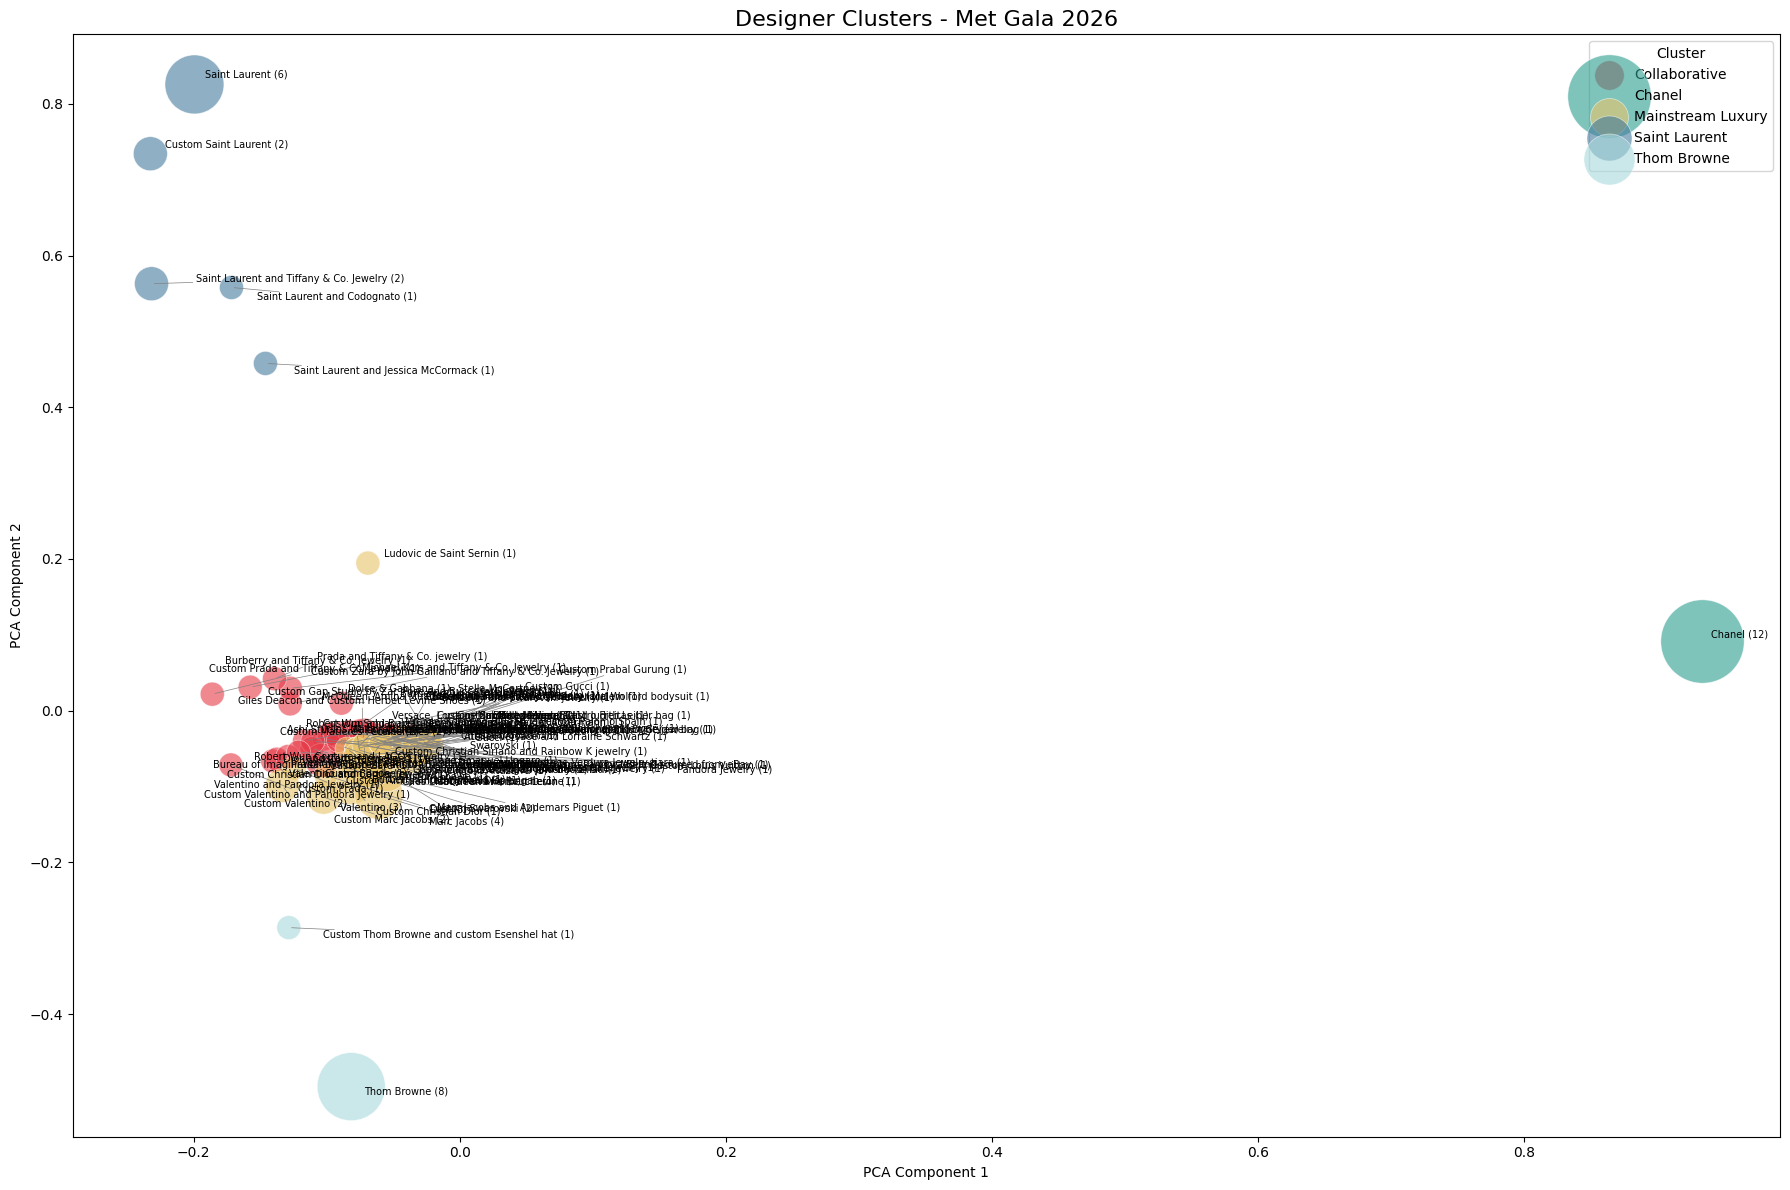

Saved to Downloads/designer_bubbles.jpg


In [11]:
import json
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Load and merge
with open("/Users/jitminaj/Downloads/vogue_images/designers.json") as f:
    vogue = json.load(f)

with open("/Users/jitminaj/Downloads/harpersbazaar_images/designers.json") as f:
    hb = json.load(f)

hb_clean = [{"celebrity": x["celebrity"], "designer": x["designer"], "caption": x["caption"]} for x in hb]

all_data = vogue + hb_clean
df = pd.DataFrame(all_data)
df = df[df["designer"] != "unknown"]

# Count how many looks per designer (for bubble size)
designer_counts = df["designer"].value_counts().reset_index()
designer_counts.columns = ["designer", "count"]
df = df.merge(designer_counts, on="designer")

# Vectorise
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["designer"])

# Cluster
kmeans = KMeans(n_clusters=5, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

# Reduce to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(X.toarray())
df["x"] = coords[:, 0]
df["y"] = coords[:, 1]

# Drop duplicates so one bubble per designer
df_unique = df.drop_duplicates(subset="designer")

colors = ["#e63946", "#2a9d8f", "#e9c46a", "#457b9d", "#a8dadc"]
cluster_names = {
    0: "Collaborative",
    1: "Chanel",
    2: "Mainstream Luxury",
    3: "Saint Laurent",
    4: "Thom Browne"
}

fig, ax = plt.subplots(figsize=(18, 12))

for cluster_id in range(5):
    mask = df_unique["cluster"] == cluster_id
    ax.scatter(
        df_unique[mask]["x"],
        df_unique[mask]["y"],
        label=cluster_names[cluster_id],
        color=colors[cluster_id],
        # Bubble size based on number of looks
        s=df_unique[mask]["count"] * 300,
        alpha=0.6,
        edgecolors="white",
        linewidths=0.5
    )

# Spread labels
texts = []
for _, row in df_unique.iterrows():
    texts.append(ax.text(
        row["x"],
        row["y"],
        f"{row['designer']} ({row['count']})",
        fontsize=7
    ))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color="grey", lw=0.5))

ax.set_title("Designer Clusters - Met Gala 2026", fontsize=16)
ax.legend(title="Cluster")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
plt.tight_layout()
plt.savefig("/Users/jitminaj/Downloads/designer_bubbles.jpg", dpi=300, bbox_inches="tight")
plt.show()

print("Saved to Downloads/designer_bubbles.jpg")


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


AttributeError: 'Axes' object has no attribute 'set_'

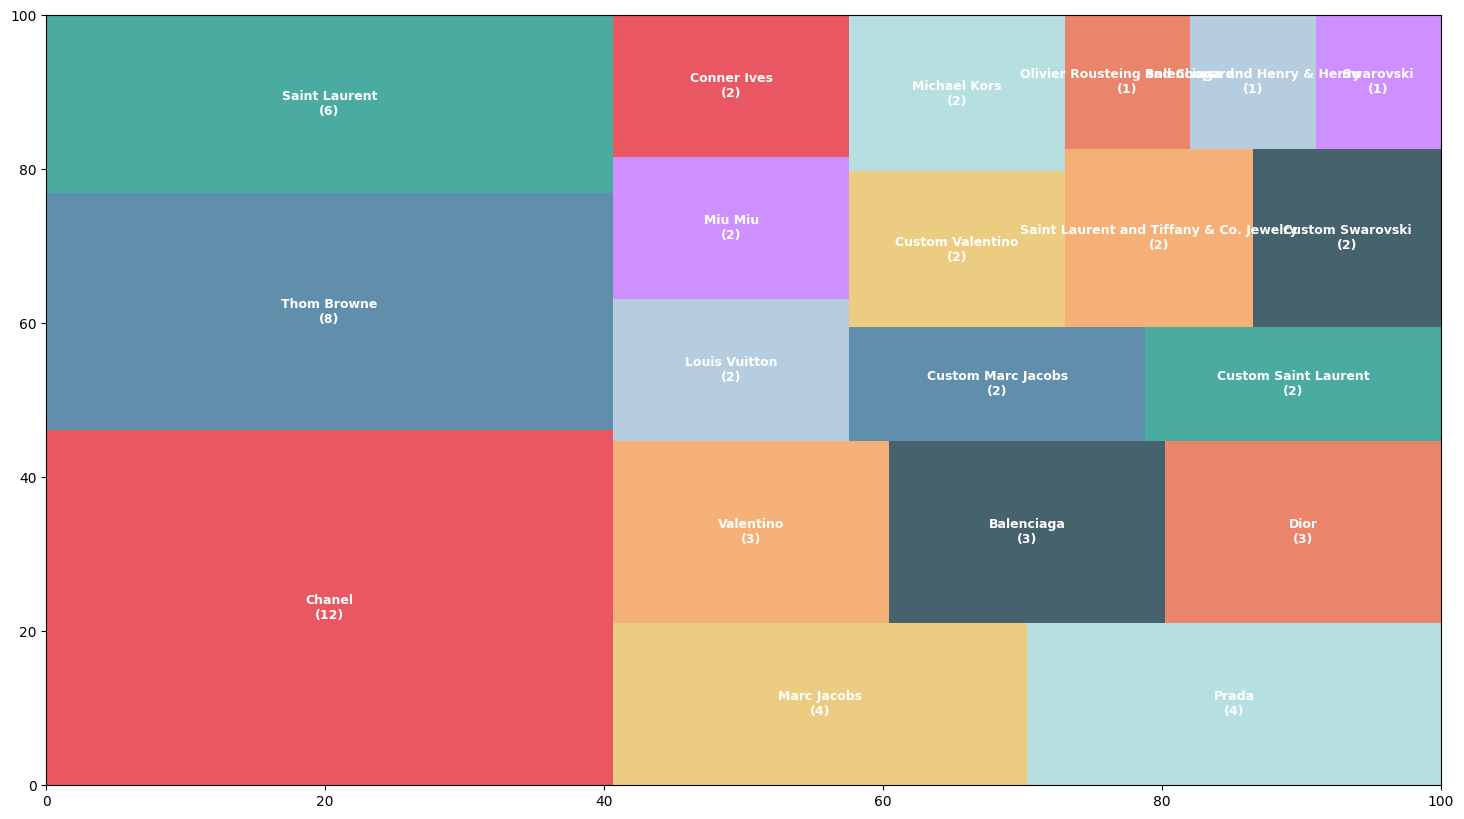

In [12]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# install squarify first
import sys
!{sys.executable} -m pip install squarify

import squarify

# Load and merge
with open("/Users/jitminaj/Downloads/vogue_images/designers.json") as f:
    vogue = json.load(f)

with open("/Users/jitminaj/Downloads/harpersbazaar_images/designers.json") as f:
    hb = json.load(f)

hb_clean = [{"celebrity": x["celebrity"], "designer": x["designer"], "caption": x["caption"]} for x in hb]

all_data = vogue + hb_clean
df = pd.DataFrame(all_data)
df = df[df["designer"] != "unknown"]

# Count looks per designer, take top 20
designer_counts = df["designer"].value_counts().head(20)

# Colours
colors = [
    "#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#a8dadc",
    "#f4a261", "#264653", "#e76f51", "#a8c5da", "#c77dff",
    "#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#a8dadc",
    "#f4a261", "#264653", "#e76f51", "#a8c5da", "#c77dff"
]

fig, ax = plt.subplots(figsize=(18, 10))

squarify.plot(
    sizes=designer_counts.values,
    label=[f"{name}\n({count})" for name, count in designer_counts.items()],
    color=colors,
    alpha=0.85,
    ax=ax,
    text_kwargs={"fontsize": 9, "color": "white", "weight": "bold"}
)

ax.set_

In [14]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


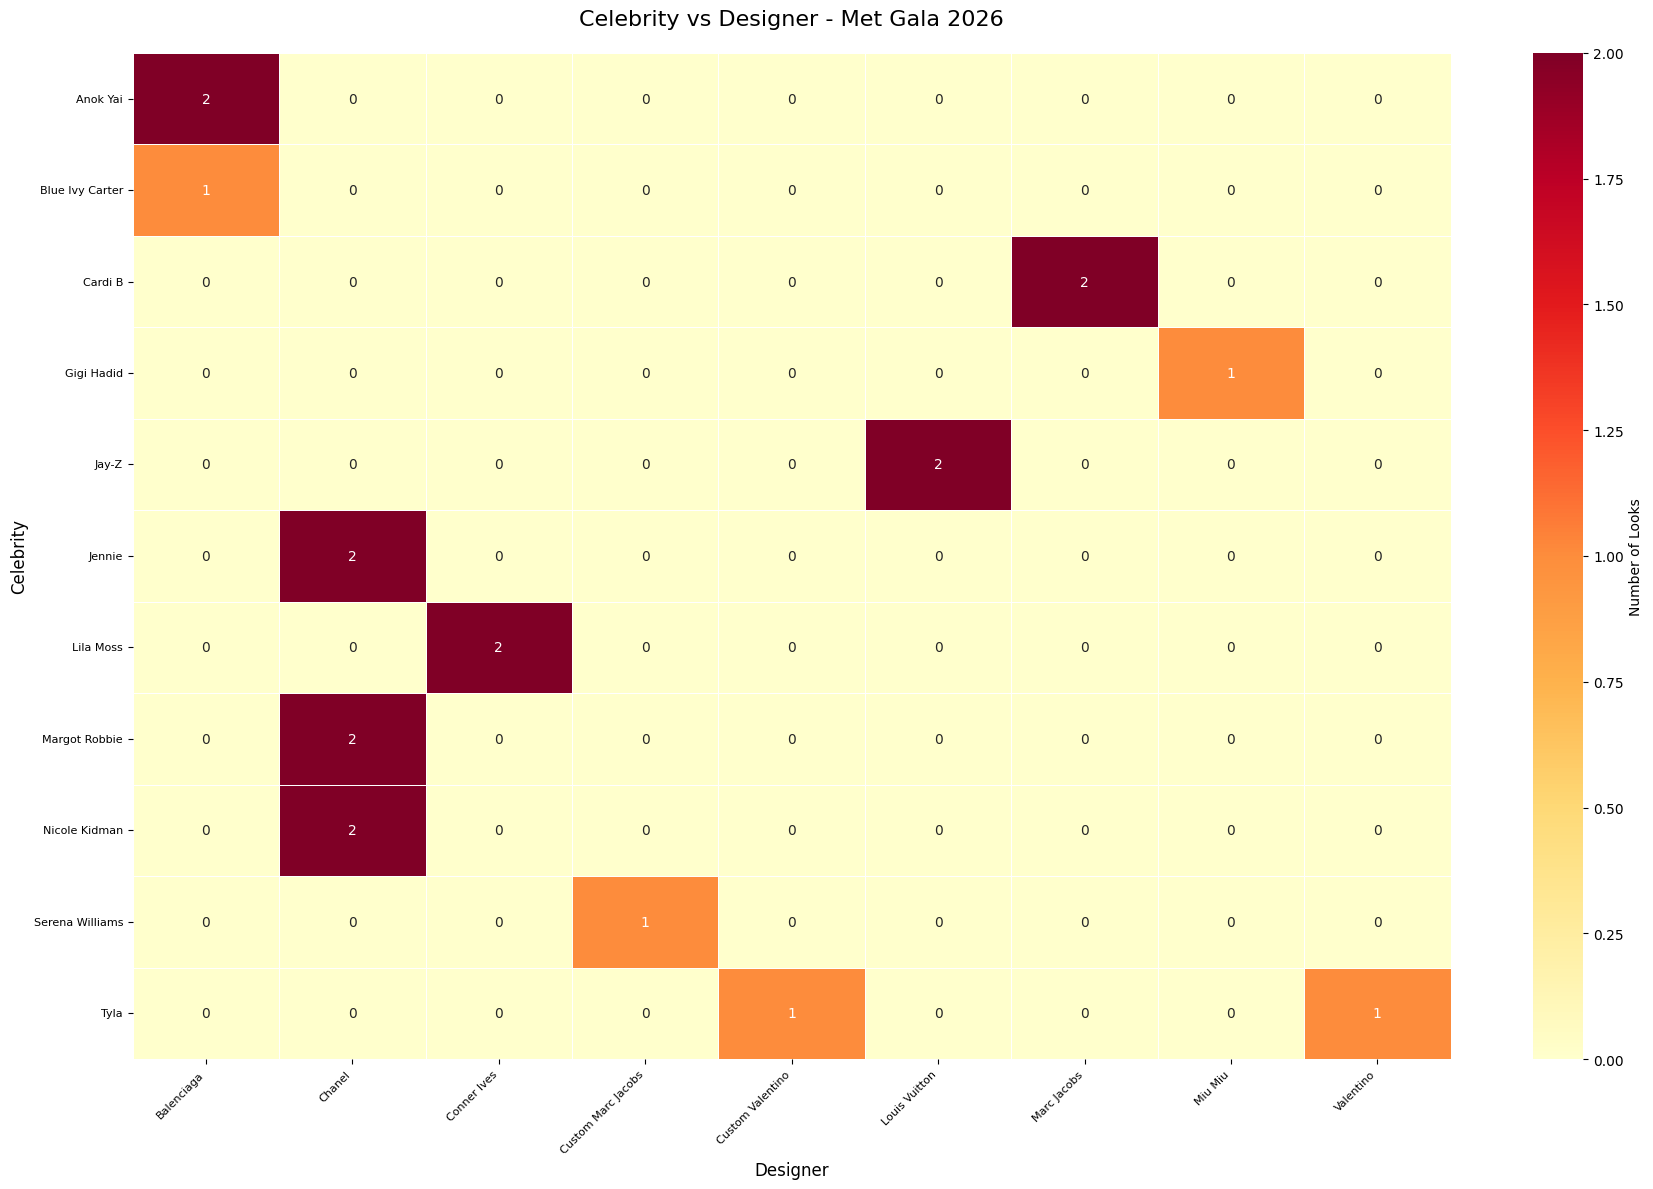

Saved to Downloads/designer_heatmap.jpg


In [15]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Install seaborn if needed
!{sys.executable} -m pip install seaborn

# Load and merge
with open("/Users/jitminaj/Downloads/vogue_images/designers.json") as f:
    vogue = json.load(f)

with open("/Users/jitminaj/Downloads/harpersbazaar_images/designers.json") as f:
    hb = json.load(f)

hb_clean = [{"celebrity": x["celebrity"], "designer": x["designer"], "caption": x["caption"]} for x in hb]

all_data = vogue + hb_clean
df = pd.DataFrame(all_data)
df = df[df["designer"] != "unknown"]

# Keep only top 15 designers and top 20 celebrities to keep it readable
top_designers = df["designer"].value_counts().head(15).index
top_celebrities = df["celebrity"].value_counts().head(20).index

df_filtered = df[df["designer"].isin(top_designers) & df["celebrity"].isin(top_celebrities)]

# Create pivot table
pivot = df_filtered.pivot_table(
    index="celebrity",
    columns="designer",
    aggfunc="size",
    fill_value=0
)

# Plot
fig, ax = plt.subplots(figsize=(18, 12))

sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt="d",
    ax=ax,
    cbar_kws={"label": "Number of Looks"}
)

ax.set_title("Celebrity vs Designer - Met Gala 2026", fontsize=16, pad=20)
ax.set_xlabel("Designer", fontsize=12)
ax.set_ylabel("Celebrity", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("/Users/jitminaj/Downloads/designer_heatmap.jpg", dpi=300, bbox_inches="tight")
plt.show()

print("Saved to Downloads/designer_heatmap.jpg")

In [16]:
import sys
!{sys.executable} -m pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 19.0 MB/s  0:00:00

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


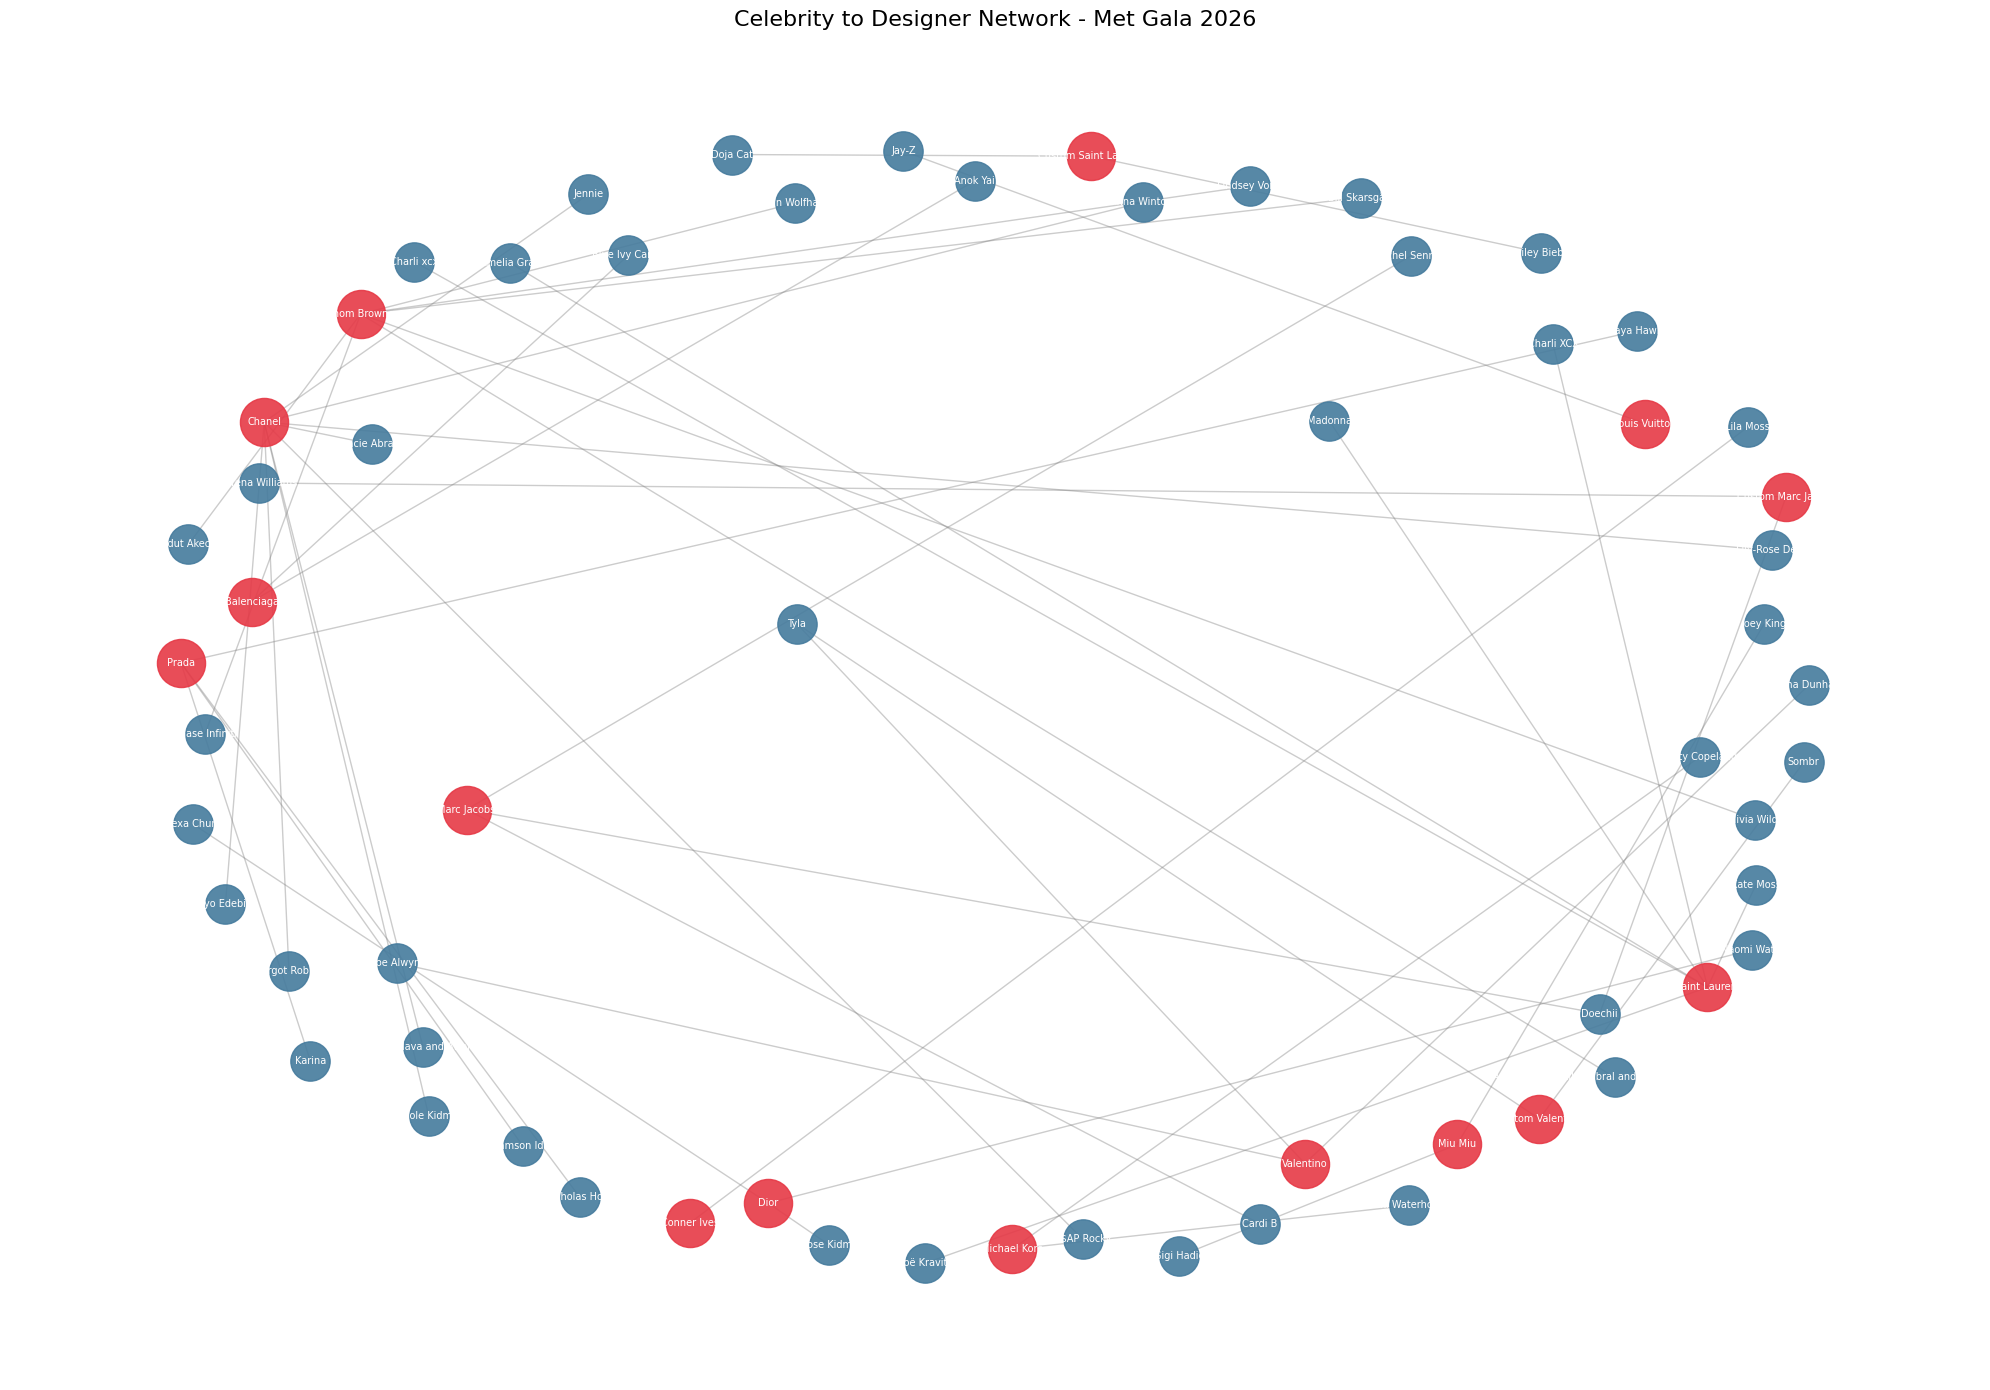

Saved to Downloads/designer_network.jpg


In [17]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Load and merge
with open("/Users/jitminaj/Downloads/vogue_images/designers.json") as f:
    vogue = json.load(f)

with open("/Users/jitminaj/Downloads/harpersbazaar_images/designers.json") as f:
    hb = json.load(f)

hb_clean = [{"celebrity": x["celebrity"], "designer": x["designer"], "caption": x["caption"]} for x in hb]

all_data = vogue + hb_clean
df = pd.DataFrame(all_data)
df = df[df["designer"] != "unknown"]

# Keep top 15 designers to avoid clutter
top_designers = df["designer"].value_counts().head(15).index
df_filtered = df[df["designer"].isin(top_designers)]

# Build network graph
G = nx.Graph()

for _, row in df_filtered.iterrows():
    celebrity = row["celebrity"]
    designer = row["designer"]
    G.add_node(celebrity, node_type="celebrity")
    G.add_node(designer, node_type="designer")
    G.add_edge(celebrity, designer)

# Separate node types for colouring
celebrity_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "celebrity"]
designer_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "designer"]

# Layout
pos = nx.spring_layout(G, seed=42, k=2)

fig, ax = plt.subplots(figsize=(20, 14))

# Draw celebrity nodes
nx.draw_networkx_nodes(G, pos, nodelist=celebrity_nodes, node_color="#457b9d", node_size=800, alpha=0.9, ax=ax)

# Draw designer nodes bigger
nx.draw_networkx_nodes(G, pos, nodelist=designer_nodes, node_color="#e63946", node_size=1200, alpha=0.9, ax=ax)

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color="grey", alpha=0.4, width=1, ax=ax)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=7, font_color="white", ax=ax)

ax.set_title("Celebrity to Designer Network - Met Gala 2026", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.savefig("/Users/jitminaj/Downloads/designer_network.jpg", dpi=300, bbox_inches="tight")
plt.show()

print("Saved to Downloads/designer_network.jpg")